<a href="https://colab.research.google.com/github/Yahir-7/GeoPandas/blob/main/Data_Centers_%C3%97_Nighttime_Light_Pollutioncorrect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2728/1718513675.py:71: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged['area'] = merged.geometry.area
/tmp/ipykernel_2728/1718513675.py:77: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged['length'] = merged.geometry.length


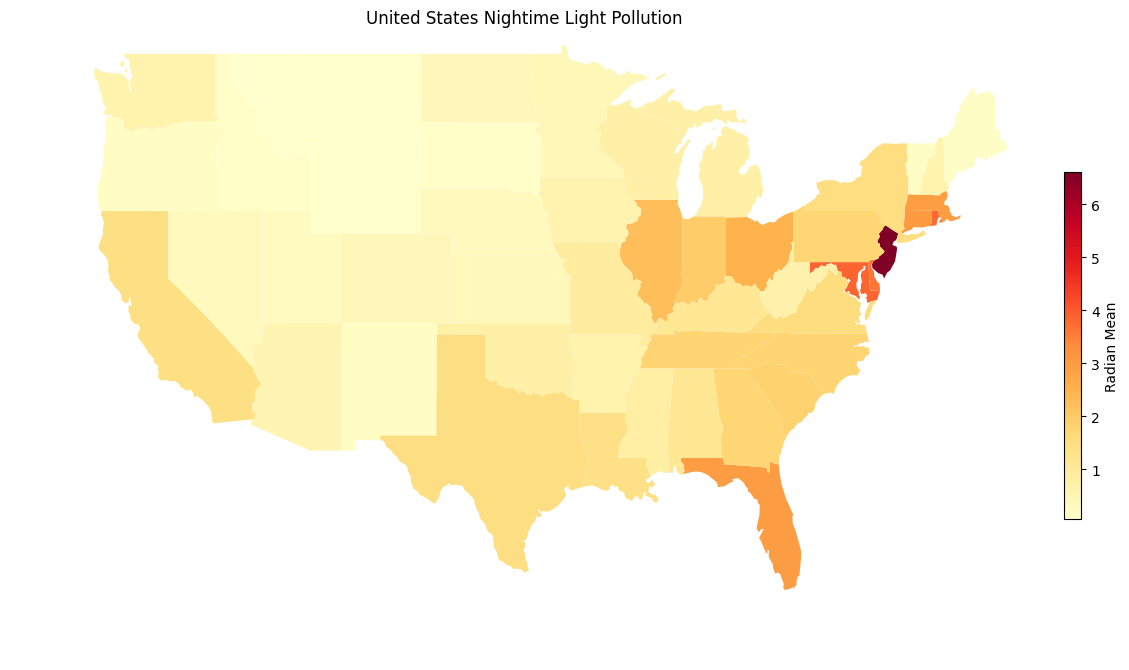

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
!pip install geodatasets




df = pd.read_excel(
    '/content/ALAN_VIIRS_CONUS_2012_to_2020_census_tract_level.xlsx',
    sheet_name='2020_boundary_ALAN_2012_to_2020'
)

gdf = df
file = gpd.GeoDataFrame(gdf)
file = file


state = file.set_index('state')
state


url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data'
state_geo = gpd.read_file(url + '/us-states.json')
state_geo

data =file[file['year']== 2020].reset_index()
data



data['weighted_rad'] = data['rad_mean'] * data['nraster']


grouped = data.groupby('state').agg({
    'weighted_rad': 'sum',
    'nraster': 'sum'
}).reset_index()

grouped['true_rad_mean'] = grouped['weighted_rad'] / grouped['nraster']






#merge w my data
merged = state_geo.merge(grouped, left_on='name', right_on='state', how='left')
merged
#adding area, boundary, length
merged['area'] = merged.geometry.area
merged['area']

merged['boundary'] = merged.geometry.boundary
merged['boundary']

merged['length'] = merged.geometry.length
merged['length']

merged['rad_mean'] = pd.to_numeric(merged['true_rad_mean'], errors='coerce')
merged['rad_mean']

fig, ax = plt.subplots(figsize=(16,9))
merged.plot(column ='rad_mean', legend=True, ax=ax, cmap='YlOrRd', legend_kwds={'label': "Radian Mean", 'orientation': "vertical", 'shrink': 0.5, 'pad' :0.02})
ax.set_xlim(-130,-65)
ax.set_ylim(22,50)
ax.set_title('United States Nightime Light Pollution')
ax.axis('off')
plt.show()


